<a href="https://colab.research.google.com/github/sarojsenn/stockmarketAnalysis/blob/main/stockMarketAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
news = pd.read_csv("/news.csv", encoding = 'latin1')

In [ ]:
news.head()

,Title,Date,Description,Author,Content,Keywords,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 179,Unnamed: 180,Unnamed: 181,Unnamed: 182,Unnamed: 183,Unnamed: 184,Unnamed: 185,Unnamed: 186,Unnamed: 187,Unnamed: 188
0,"Aurobindo Pharma, Dr Reddy's, Lupin, other pha...",08-07-2025,'A renewed push for 'Buy America' could compli...,Debaroti Adhikary,The shares of Indian pharma companies dropped ...,"pharma stocks, Nifty Pharma, Aurobindo Pharma ...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bharti Airtel share price falls 1.53%; stock a...,18-07-2025,"With the stock currently trading at Rs 1,900.4...",Alpha Desk,Shares of Bharti Airtel were trading lower at ...,"Bharti Airtel, shares, stock price, Nifty 50, ...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indian Oil and Adani Gas JV plans $161 million...,09-07-2025,The city gas distribution firms deal could be...,Bloomberg,IndianOil-Adani Gas Pvt. is planning to raise ...,"IndianOil-Adani Gas, IOC, convertible bond sale",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Cipla Shares Fall in Today's Trading Session A...,03-06-2025,"The stock's last traded price is Rs 1,461.30, ...",Alpha Desk,"During today's trading session, Cipla expe...","Cipla, stock market, financial performance, re...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Here are the sectors and stocks in focus amids...,07-02-2025,With the recent liquidity injection by the Res...,Anishaa Kumar,"Sectors such as consumer durables, financials,...","MPC, RBI, stocks",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
news.columns

Index(['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'],
      dtype='object', length=189)

In [ ]:
print(news[['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords']].notna().sum())

Title          3349
Date           3349
Description    2858
Author         3349
Content        3349
Keywords       3347
dtype: int64


In [ ]:
news = news[['Date', 'Title']]

In [ ]:
news.head()

,Date,Title
0,08-07-2025,"Aurobindo Pharma, Dr Reddy's, Lupin, other pha..."
1,18-07-2025,Bharti Airtel share price falls 1.53%; stock a...
2,09-07-2025,Indian Oil and Adani Gas JV plans $161 million...
3,03-06-2025,Cipla Shares Fall in Today's Trading Session A...
4,07-02-2025,Here are the sectors and stocks in focus amids...


In [ ]:
news.isnull().sum()

,0
Date,0
Title,0


In [ ]:
news.duplicated().sum()

np.int64(1)

In [ ]:
news = news.dropna().drop_duplicates()

In [ ]:
news['Title'] = news['Title'].str.strip()

In [ ]:
news.head()

,Date,Title
0,08-07-2025,"Aurobindo Pharma, Dr Reddy's, Lupin, other pha..."
1,18-07-2025,Bharti Airtel share price falls 1.53%; stock a...
2,09-07-2025,Indian Oil and Adani Gas JV plans $161 million...
3,03-06-2025,Cipla Shares Fall in Today's Trading Session A...
4,07-02-2025,Here are the sectors and stocks in focus amids...


In [ ]:
news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3348 entries, 0 to 3348
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3348 non-null   object
 1   Title   3348 non-null   object
dtypes: object(2)
memory usage: 78.5+ KB


In [ ]:
news.describe()

,Date,Title
count,3348,3348
unique,174,3306
top,29-07-2025,Buy Adani Ports and SEZ; target of Rs 1700: Mo...
freq,75,3


In [ ]:
grouped_news = (news.groupby("Date")["Title"].apply(list).reset_index())

In [ ]:
grouped_news.head()

,Date,Title
0,just some time back that you resisted going t...,[ur. You're always in a t-shirt. Like you said]
1,01-04-2025,[Indian companies gear up for nuclear expansio...
2,01-05-2025,[Adani Enterprises Q4 Results: Net profit rise...
3,01-06-2025,"[Trade Spotlight: How should you trade CDSL, M..."
4,01-07-2025,[PSU bank stocks snap 5-day gaining streak ami...


In [ ]:
grouped_news = grouped_news.iloc[1:]

In [ ]:
grouped_news.head()

,Date,Title
1,01-04-2025,[Indian companies gear up for nuclear expansio...
2,01-05-2025,[Adani Enterprises Q4 Results: Net profit rise...
3,01-06-2025,"[Trade Spotlight: How should you trade CDSL, M..."
4,01-07-2025,[PSU bank stocks snap 5-day gaining streak ami...
5,01-08-2025,[ITC share price gain 1.27% in friday's tradin...


In [ ]:
grouped_news['Date'] = pd.to_datetime(
    grouped_news['Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [ ]:
grouped_news['Date'].head()

,Date
1,2025-04-01
2,2025-05-01
3,2025-06-01
4,2025-07-01
5,2025-08-01


In [ ]:
grouped_news.to_csv("grouped_news.csv", index = False)

#Cleaning the NIFTY50 Data


In [ ]:
stock = pd.read_csv("/nifty50.csv", encoding = 'cp1252')

In [ ]:
stock.head()

,ï»¿Date,Open,High,Low,Close,Shares Traded,Turnover (â‚¹ Cr)
0,29-AUG-2025,24466.70,24572.45,24404.70,24426.85,325543583,26796.69
1,28-AUG-2025,24695.80,24702.65,24481.60,24500.90,326601486,29371.67
2,26-AUG-2025,24899.50,24919.65,24689.60,24712.05,750473927,47068.20
3,25-AUG-2025,24949.15,25021.55,24894.35,24967.75,213032133,19871.25
4,22-AUG-2025,25064.15,25084.85,24859.15,24870.10,210165384,19655.78


In [ ]:
stock.columns


Index(['ï»¿Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (â‚¹ Cr)'],
      dtype='object')

In [ ]:
##Renaming stock columns
stock.columns = ['date', 'open', 'high', 'low', 'close', 'shares traded', 'turnover_cr']

In [ ]:
stock['shares traded'] = stock['shares traded'].astype(float)

In [ ]:
stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')

In [ ]:
merged = pd.merge(stock, grouped_news, left_on = 'date', right_on = 'Date', how = 'inner')

In [ ]:
print(merged.isnull().sum())

date             0
open             0
high             0
low              0
close            0
shares traded    0
turnover_cr      0
Date             0
Title            0
dtype: int64


In [ ]:
merged['movement'] = merged['close'] - merged['open']
def check_movement(x):
  if x>0:
    return 1
  else:
    return 0
merged['target'] = merged['movement'].apply(check_movement)

In [ ]:
positive_words = [
    'gain', 'gains', 'gained', 'gainers', 'gainer',
    'growth', 'grew', 'grow', 'growing',
    'profit', 'profitable', 'profitability', 'profits',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'jump', 'jumps', 'jumped', 'jumping',
    'soar', 'soars', 'soared', 'soaring',
    'climb', 'climbs', 'climbed', 'climbing',
    'advance', 'advances', 'advanced', 'advancing',
    'recover', 'recovery', 'recovered', 'recovering', 'recovers',
    'rebound', 'rebounds', 'rebounded', 'rebounding',
    'upturn', 'upswing', 'uptrend', 'upside',
    'boom', 'booming', 'boomed',
    'bullish', 'bull', 'bull run',
    'outperform', 'outperforms', 'outperformed', 'outperforming',
    'beat', 'beats', 'beaten',
    'exceed', 'exceeds', 'exceeded', 'exceeding',
    'strong', 'stronger', 'strongest', 'strengthen', 'strengthens',
    'robust', 'resilient', 'resilience',
    'positive', 'positively',
    'optimism', 'optimistic', 'optimist',
    'confidence', 'confident',
    'momentum', 'accelerate', 'accelerating', 'acceleration',
    'record', 'record-high', 'all-time high', 'peak', 'peaked',
    'high', 'highs', 'higher', 'highest',
    'milestone', 'breakthrough',
    'expand', 'expansion', 'expands', 'expanded', 'expanding',
    'upgrade', 'upgraded', 'upgrades',
    'buy', 'buying',
    'invest', 'investment', 'investing', 'investor', 'investors',
    'inflow', 'inflows',
    'net profit', 'net sales', 'revenue',

    'earnings', 'earning',
    'dividend', 'dividends',
    'bonus', 'windfall',
    'order win', 'order book', 'order inflow',
    'contract win', 'new contract',
    'acquisition', 'merger', 'deal',
    'partnership', 'collaboration', 'agreement',
    'launch', 'launches', 'launched', 'launching',
    'nod', 'approval', 'approved', 'approve',
    'clearance', 'cleared',
    'listing', 'listed', 'debut',
    'ipo', 'initial public offering',
    'fdi', 'foreign investment',
    'fund inflow',
    'target', 'price target',
    'recommendation', 'recommend',
    'bullish outlook', 'positive outlook',
    'ebitda', 'margin expansion',
    'market share', 'market cap',
    'steady', 'stable', 'stability',
    'demand', 'demand recovery', 'demand growth',
    'consumption', 'consumption growth',
    'export', 'exports', 'export growth',
    'sales growth', 'revenue growth', 'profit growth',
    'year-on-year', 'y-o-y', 'yoy',
    'quarter-on-quarter', 'qoq',
    'multi-year high', '52-week high',
    'all-time', 'historic high',
    'interest rate cut', 'rate cut',
    'fiscal stimulus', 'stimulus',
    'gdp growth', 'economic growth',
    'reform', 'reforms', 'reforming',
    'deregulation', 'liberalisation', 'liberalization',
    'tax relief', 'tax cut', 'tax benefit',
    'subsidy', 'subsidies',
    'infrastructure spend', 'capex',
    'innovation', 'innovate', 'innovative',
    'technology upgrade', 'digital transformation',
    'efficiency', 'efficient',
    'cost savings', 'cost reduction',
    'margin improvement', 'operating leverage',
    'value creation', 'shareholder value',
    'buyback', 'share buyback', 'repurchase',
    'esop', 'stock options',
    'accretive', 'value accretive',
    'synergy', 'synergies',
    'turnaround',
    'green shoot', 'green shoots',
    'soft landing',
    'credit upgrade', 'rating upgrade',
    'debt reduction', 'deleveraging',
    'asset light', 'capital efficient',
    'guidance raised', 'guidance upgrade',
    'estimate beat', 'earnings beat',
    'net interest margin', 'nim improvement',
    'npa reduction', 'asset quality improvement',
    'loan growth', 'credit growth',
    'deposit growth',
    'capacity addition', 'capacity expansion',
    'new plant', 'greenfield', 'brownfield',
    'foray', 'diversification',
    'market leader', 'market leadership',
    'premium', 'premiumisation',
    'high demand', 'strong demand',
    'oversubscribed', 'oversubscription',
    'favourable', 'favorable',
    'tailwind', 'tailwinds',
    'healthy', 'healthier',
    'superior', 'superlative',
    'exceptional', 'excellent',
    'impressive', 'remarkable',
    'notable', 'noteworthy',
    'significant upside', 'upside potential',
    're-rating',
    'value unlocking',
    'listed gains', 'listing gains',
    'multibagger',
    'broad-based rally', 'across-the-board gains',
    'fresh buying', 'accumulate', 'accumulation',
    'long position', 'long buildup',
    'covers', 'short covering',
    'supportive policy', 'policy support',
    'global cues positive', 'positive global cues',
]

negative_words = [
    'loss', 'losses', 'lost', 'lose', 'losing',
    'decline', 'declines', 'declined', 'declining',
    'fall', 'falls', 'fell', 'fallen', 'falling',
    'drop', 'drops', 'dropped', 'dropping',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plunges', 'plunged', 'plunging',
    'tumble', 'tumbles', 'tumbled', 'tumbling',
    'slump', 'slumps', 'slumped', 'slumping',
    'slide', 'slides', 'slid', 'sliding',
    'sink', 'sinks', 'sank', 'sunk', 'sinking',
    'dip', 'dips', 'dipped', 'dipping',
    'plummet', 'plummets', 'plummeted', 'plummeting',
    'nosedive', 'nosedived',
    'collapse', 'collapses', 'collapsed', 'collapsing',
    'downturn', 'downswing', 'downtrend', 'downside',
    'bearish', 'bear', 'bear run', 'bear market',
    'underperform', 'underperforms', 'underperformed', 'underperforming',
    'miss', 'misses', 'missed',
    'below estimate', 'below expectations', 'below forecast',
    'weak', 'weaker', 'weakest', 'weaken', 'weakening', 'weakness',
    'fragile', 'vulnerable', 'vulnerability',
    'negative', 'negatively',
    'pessimism', 'pessimistic',
    'concern', 'concerns', 'concerned', 'concerning',
    'worry', 'worries', 'worried', 'worrying',
    'uncertainty', 'uncertain', 'unpredictable',
    'risk', 'risks', 'risky', 'riskier',
    'low', 'lows', 'lower', 'lowest',
    '52-week low', 'multi-year low', 'historic low',
    'all-time low',
    'downgrade', 'downgraded', 'downgrades',
    'sell', 'selling', 'selloff', 'sell-off',
    'outflow', 'outflows', 'fund outflow',
    'net loss', 'net deficit',
    'revenue decline', 'sales decline',
    'profit decline', 'profit fall',
    'margin pressure', 'margin compression', 'margin erosion',
    'earnings miss', 'estimate miss',
    'guidance cut', 'guidance reduced', 'guidance lowered',
    'guidance withdrawn',
    'cost pressure', 'cost inflation', 'input cost',
    'inflation', 'inflationary', 'hyperinflation',
    'recession', 'recessionary',
    'stagflation',
    'slowdown', 'slow growth', 'deceleration',
    'contraction', 'economic contraction',
    'gdp decline', 'gdp contraction',
    'unemployment', 'job cuts', 'layoffs', 'retrenchment',
    'downsizing',
    'tariff', 'tariffs', 'trade war', 'trade tensions',
    'sanctions', 'sanction',
    'ban', 'banned', 'prohibit',
    'regulation', 'regulatory hurdle', 'regulatory risk',
    'investigation', 'probe', 'scrutiny',
    'penalty', 'penalties', 'fine', 'fines',
    'fraud', 'scam', 'scandal',
    'default', 'defaults', 'defaulted', 'defaulting',
    'bankruptcy', 'insolvency', 'insolvent',
    'liquidation', 'liquidate', 'winding up',
    'debt', 'high debt', 'debt burden', 'overleveraged',
    'npa', 'bad loan', 'bad loans', 'non-performing',
    'write-off', 'write-offs',
    'provisioning', 'provisions',
    'credit downgrade', 'rating downgrade',
    'interest rate hike', 'rate hike', 'rate increase',
    'tightening', 'monetary tightening', 'hawkish',
    'currency depreciation', 'rupee fall', 'currency risk',
    'foreign exchange loss', 'forex loss',
    'geopolitical risk', 'geopolitical tension',
    'war', 'conflict', 'tension',
    'supply chain disruption', 'supply shortage',
    'shortage', 'scarcity',
    'demand slump', 'demand weakness', 'weak demand',
    'overcapacity', 'oversupply',
    'inventory build', 'inventory pile',
    'import pressure',
    'competition', 'competitive pressure',
    'market share loss',
    'customer churn',
    'resignation', 'exit', 'step down', 'stepped down',
    'resignation of cfo', 'ceo quits', 'management exit',
    'stake sale', 'promoter selling',
    'dilution', 'equity dilution',
    'block deal loss', 'block deal exit',
    'halt', 'suspension', 'suspended',
    'noc rejected', 'approval denied',
    'order cancellation', 'contract cancellation',
    'project delay', 'delayed',
    'headwinds', 'headwind',
    'adverse', 'adversely',
    'unfavourable', 'unfavorable',
    'caution', 'cautious',
    'underweight',
    'cut', 'cuts', 'price cut',
    'slash', 'slashed', 'slashes',
    'bleed', 'bleeding',
    'erosion',
    'pressure', 'pressured', 'under pressure',
    'drag', 'drags', 'dragged',
    'drag on earnings',
    'loser', 'losers', 'top loser',
    'bottom performer',
    'stress', 'distress', 'financial stress',
    'short position', 'short buildup', 'short selling',
    'circuit breaker', 'lower circuit',
    'sell-on-rise', 'profit booking',
    'unwinding',
    'global cues negative', 'negative global cues',
    'fii selling', 'dii selling', 'institutional selling',
    'correction', 'market correction', 'broad-based selloff',
]

In [ ]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0
    for word in positive_words:
        score += text.count(word)
    for word in negative_words:
        score -= text.count(word)
    return score

In [ ]:
merged['sentiment_score'] = merged['Title'].apply(sentiment_score)

In [ ]:
merged.head()

,date,open,high,low,close,shares traded,turnover_cr,Date,Title,movement,target,sentiment_score
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ...",-58.25,0,6
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...,84.75,1,8
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...,89.30,1,9
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc...",-61.25,0,20
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...,24.05,1,8


In [ ]:
merged.describe()

,date,open,high,low,close,shares traded,turnover_cr,Date,movement,target,sentiment_score
count,132,132.000000,132.000000,132.000000,132.000000,1.320000e+02,132.000000,132,132.000000,132.000000,132.000000
mean,2025-05-17 16:21:49.090909184,24176.768182,24293.575000,24062.864015,24185.400379,3.337581e+08,28486.718182,2025-05-17 16:21:49.090909184,8.632197,0.492424,18.166667
min,2025-02-07 00:00:00,21758.400000,22105.050000,21743.650000,22082.650000,1.935116e+08,16923.260000,2025-02-07 00:00:00,-312.300000,0.000000,-24.000000
25%,2025-03-27 18:00:00,23303.975000,23384.625000,23143.450000,23308.937500,2.594826e+08,23028.160000,2025-03-27 18:00:00,-90.112500,0.000000,4.000000
50%,2025-05-20 12:00:00,24574.775000,24688.125000,24483.725000,24590.600000,3.058779e+08,26379.540000,2025-05-20 12:00:00,-6.700000,0.000000,13.000000
75%,2025-07-04 18:00:00,24968.812500,25064.712500,24832.637500,24974.087500,3.772944e+08,31109.287500,2025-07-04 18:00:00,94.462500,1.000000,31.250000
max,2025-08-21 00:00:00,25661.650000,25669.350000,25523.550000,25637.800000,8.538910e+08,55782.030000,2025-08-21 00:00:00,504.600000,1.000000,88.000000
std,NaN,1026.689195,1007.266599,1027.815557,1011.852030,1.077898e+08,7621.033664,NaN,155.551094,0.501847,22.537557


In [ ]:
merged['sentiment_score'].value_counts()

,count
sentiment_score,
7,7
10,6
8,5
6,4
9,4
...,...
12,1
-20,1
-7,1


In [ ]:
merged.groupby('target')['sentiment_score'].mean()

,sentiment_score
target,
0,14.805970
1,21.630769


In [ ]:
import os

os.makedirs(
    "plots",
    exist_ok=True
)

In [ ]:
import matplotlib.pyplot as plt



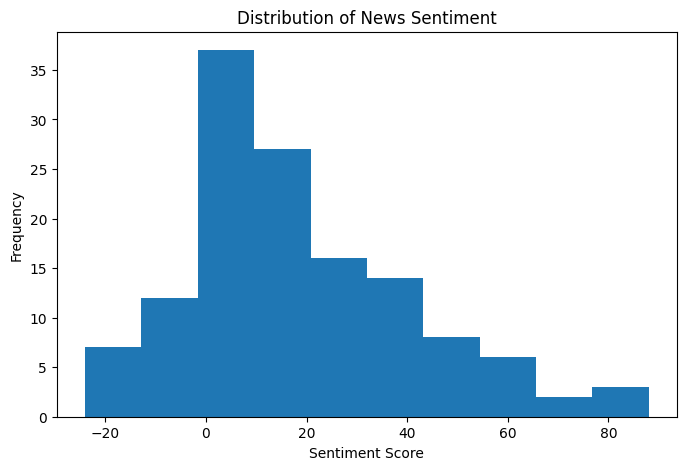

In [ ]:
#Histogram
plt.figure(figsize=(8,5))

plt.hist(merged['sentiment_score'])

plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment")

plt.savefig(
    "plots/histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

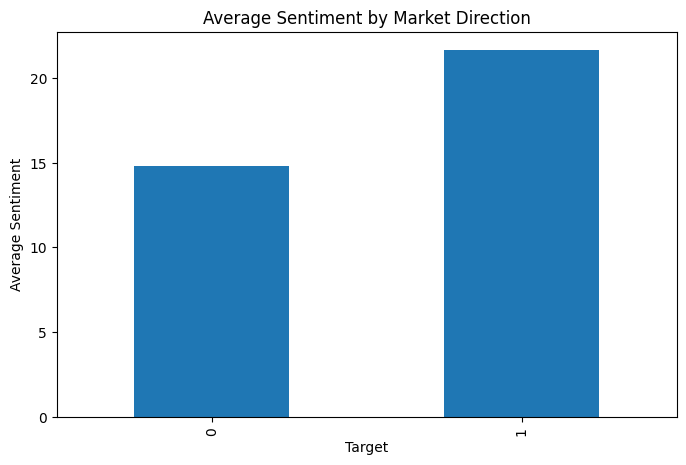

In [ ]:
##Barplot

plt.figure(figsize=(8,5))

merged.groupby('target')['sentiment_score'].mean().plot(
    kind='bar'
)

plt.xlabel("Target")
plt.ylabel("Average Sentiment")

plt.title(
    "Average Sentiment by Market Direction"
)

plt.savefig(
    "plots/barplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

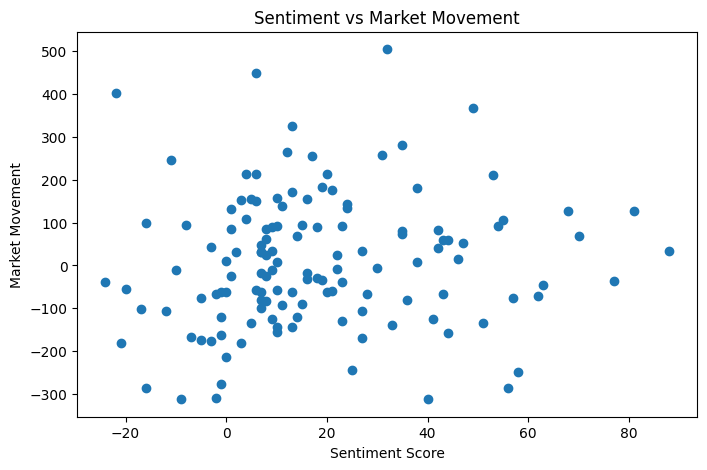

In [ ]:
#Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(
    merged['sentiment_score'],
    merged['movement']
)

plt.xlabel("Sentiment Score")
plt.ylabel("Market Movement")

plt.title(
    "Sentiment vs Market Movement"
)

plt.savefig(
    "plots/scatterplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
def predict_market(score):

    if score > 0:
        return "UP"

    elif score < 0:
        return "DOWN"

    else:
        return "NEUTRAL"

In [ ]:
merged['prediction'] = merged[
    'sentiment_score'
].apply(predict_market)

print(
    merged[
        ['date',
         'sentiment_score',
         'prediction']
    ].head()
)

        date  sentiment_score prediction
0 2025-08-21                6         UP
1 2025-08-20                8         UP
2 2025-08-19                9         UP
3 2025-08-18               20         UP
4 2025-08-14                8         UP


In [ ]:
def binary_prediction(score):

    if score > 0:
        return 1

    return 0

In [ ]:
merged['prediction_binary'] = merged[
    'sentiment_score'
].apply(binary_prediction)

In [ ]:
accuracy = (merged['prediction_binary']==merged['target']).mean()
print()
print("Prediction Accuracy:")
print(round(accuracy*100, 2),"%")


Prediction Accuracy:
59.85 %


In [ ]:
# Compute majority-class baseline
baseline = (merged['target'] == merged['target'].mode()[0]).mean()
print(f"Prediction Accuracy: {round(accuracy * 100, 2)}%")
print(f"Majority-Class Baseline: {round(baseline * 100, 2)}%")


Prediction Accuracy: 59.85%
Majority-Class Baseline: 50.76%


In [ ]:
merged.to_csv("final_project_dataset.csv", index=False)
print("Final dataset saved successfully.")

Final dataset saved successfully.


#Machine Learning Pipeline


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
ml_df = pd.read_csv('final_project_dataset.csv', parse_dates=['date'])
ml_df = ml_df.sort_values('date').reset_index(drop=True)
ml_df['next_day_target'] = ml_df['target'].shift(-1)
ml_df = ml_df.dropna(subset=['next_day_target'])
ml_df['next_day_target'] = ml_df['next_day_target'].astype(int)

In [ ]:
# Rolling sentiment features
ml_df['sentiment_ma3'] = ml_df['sentiment_score'].rolling(3).mean()
ml_df['sentiment_ma7'] = ml_df['sentiment_score'].rolling(7).mean()
ml_df['sentiment_std3'] = ml_df['sentiment_score'].rolling(3).std()
# Lagged price action (avoids leaking same-day info about the target)
ml_df['movement_lag1'] = ml_df['movement'].shift(1)
ml_df['movement_lag2'] = ml_df['movement'].shift(2)
# Volume and volatility proxies, from columns already in the dataset
ml_df['volume_change'] = ml_df['shares traded'].pct_change()
ml_df['high_low_spread'] = (ml_df['high'] - ml_df['low']) / ml_df['open'] * 100
ml_df = ml_df.dropna().reset_index(drop=True)
print(ml_df.shape)

(125, 22)


In [ ]:
feature_cols = ['sentiment_score', 'sentiment_ma3', 'sentiment_ma7', 'sentiment_std3',
'movement_lag1', 'movement_lag2', 'volume_change', 'high_low_spread']

X = ml_df[feature_cols]
y = ml_df['next_day_target']
split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f'Train: {X_train.shape[0]} days | Test: {X_test.shape[0]} days')

Train: 100 days | Test: 25 days


In [ ]:
majority_baseline = (y_test == y_test.mode()[0]).mean()
print('Majority-class baseline (test period):', round(majority_baseline*100, 2), '%')

Majority-class baseline (test period): 56.0 %


In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print('Logistic Regression accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression accuracy: 0.44
              precision    recall  f1-score   support

           0       0.50      0.43      0.46        14
           1       0.38      0.45      0.42        11

    accuracy                           0.44        25
   macro avg       0.44      0.44      0.44        25
weighted avg       0.45      0.44      0.44        25



In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
n_estimators=300, max_depth=5, min_samples_leaf=10,
random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest accuracy: 0.52
              precision    recall  f1-score   support

           0       0.58      0.50      0.54        14
           1       0.46      0.55      0.50        11

    accuracy                           0.52        25
   macro avg       0.52      0.52      0.52        25
weighted avg       0.53      0.52      0.52        25



In [ ]:
#Gradient Boosting
!pip install xgboost -q
from xgboost import XGBClassifier
xgb = XGBClassifier(
n_estimators=200, max_depth=3, learning_rate=0.05,
subsample=0.8, colsample_bytree=0.8,
eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('XGBoost accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost accuracy: 0.4
              precision    recall  f1-score   support

           0       0.46      0.43      0.44        14
           1       0.33      0.36      0.35        11

    accuracy                           0.40        25
   macro avg       0.40      0.40      0.40        25
weighted avg       0.41      0.40      0.40        25



In [ ]:
#Timeseries split + GridCV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [3, 5, 7],
'min_samples_leaf': [5, 10, 20]
}
grid_search = GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)
print('Best params:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)
best_rf = grid_search.best_estimator_
print('Tuned test accuracy:', accuracy_score(y_test, best_rf.predict(X_test)))

Best params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
Best CV accuracy: 0.5125
Tuned test accuracy: 0.44


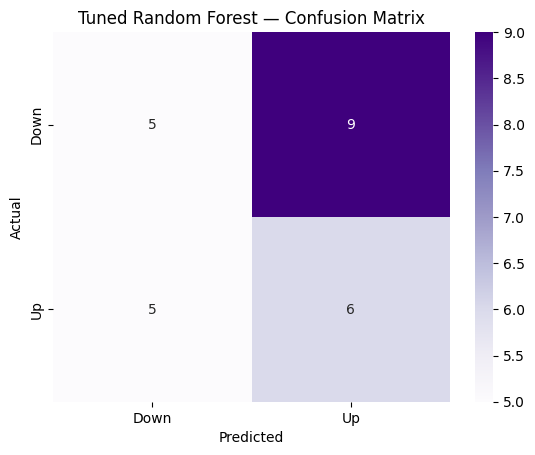

In [ ]:
#Confusion Matrix Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, best_rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
xticklabels=['Down','Up'], yticklabels=['Down','Up'])

plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Tuned Random Forest — Confusion Matrix')
plt.show()

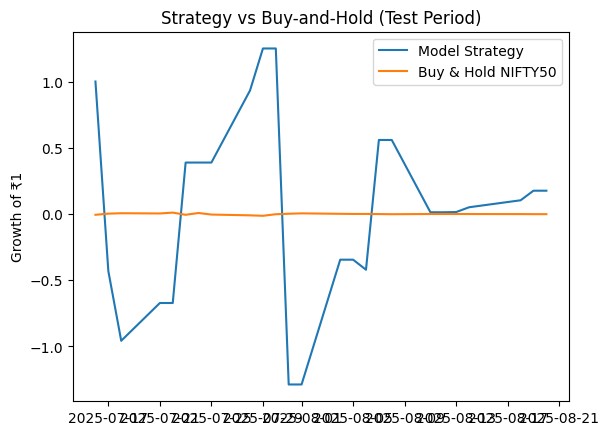

In [ ]:
#Simple Backtest vs Buy and Hold
test_df = ml_df.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = best_rf.predict(X_test)
# Strategy: go long only on days predicted 'Up' (1), otherwise stay in cash
test_df['next_day_return_pct'] = (test_df['close'].shift(-1) - test_df['close'])
test_df['close'] * 100
test_df['strategy_return'] = np.where(test_df['pred'] == 1,
test_df['next_day_return_pct'], 0)
test_df['cumulative_strategy'] = (1 +
test_df['strategy_return'].fillna(0)/100).cumprod()
test_df['cumulative_market'] = (1 +
test_df['next_day_return_pct'].fillna(0)/100).cumprod()
plt.plot(test_df['date'], test_df['cumulative_strategy'], label='Model Strategy')
plt.plot(test_df['date'], test_df['cumulative_market'], label='Buy & Hold NIFTY50')
plt.legend(); plt.title('Strategy vs Buy-and-Hold (Test Period)')
plt.ylabel('Growth of ₹1'); plt.show()

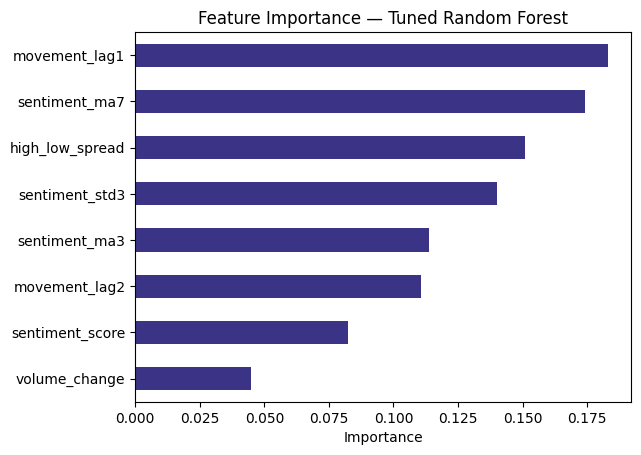

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', color='#3B3486')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')
plt.show()